# task 1 - Practice
- load a single spleen NIfTI volume,
- apply MONAI transforms
- visualize a slice with its label overlaid

In [4]:
# C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen

In [55]:
# Imports
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    RandSpatialCropd,
    RandCropd,
    RandFlipd, 
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
    KeepLargestConnectedComponent,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
import matplotlib.patches as mpatches
from monai.config import print_config
from monai.apps import download_and_extract
from flask import json
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob
import numpy as np


import time
import mlflow
import nibabel as nib


print_config()

MONAI version: 1.5.2
Numpy version: 2.4.4
Pytorch version: 2.6.0+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: d:\Summer_Projects_2026\ct-segmentation-monai\summer_01_env\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.4.2
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: 2.20.0
gdown version: 6.0.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 3.12.0
pynrrd version: 1.1.3
clearml version: 2.1.7

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [6]:
# Get the dataset directory
data_dir = r"C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen"

if not os.path.exists(data_dir):
    #download_and_extract(resource, compressed_file, root_dir, md5)
    print("Error: Data file not found. Please download the dataset manually and place it in the specified directory.")

In [7]:
# load training data file paths and split into training and validation sets
train_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))
data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(train_images, train_labels)
]
train_files, val_files = data_dicts[:-9], data_dicts[-9:]
print(train_files[0]["image"])
path = train_files[0]["image"]
print(os.path.exists(path))

img = nib.load(train_files[0]["image"])
print(img.shape)

# data_dir = r"C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen"

# train_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
# train_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))

# data_dicts = [
#     {"image": img, "label": lbl}
#     for img, lbl in zip(train_images, train_labels)
# ]

C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen\imagesTr\spleen_10.nii.gz
True
(512, 512, 55)


In [8]:
# delete later
import os
import nibabel as nib

path = train_files[0]["image"]

print("Exists:", os.path.exists(path))

try:
    img = nib.load(path)
    print("Shape:", img.shape)
except Exception as e:
    print("FAILED TO LOAD")
    print(e)

Exists: True
Shape: (512, 512, 55)


In [9]:
# from monai.transforms import Compose, LoadImaged

# loader = Compose([LoadImaged(keys=["image", "label"])])

# for i in range(len(train_files)):
#     try:
#         loader(train_files[i])
#     except Exception as e:
#         print("❌ FAILED INDEX:", i)
#         print("Image:", train_files[i]["image"])
#         print("Label:", train_files[i]["label"])
#         print(e)
#         break

In [10]:
set_determinism(seed=1)

In [11]:
# Setup Transforms to augment the dataset

# Preprocessing for training data
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]), # load the image and label from NlfTI files
        EnsureChannelFirstd(keys=["image", "label"]), # ensure channel first shape
        ScaleIntensityRanged( #normalize medical image intensites
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True), #crop medical images to remove unnecessary background and focus on the region of interest
        Orientationd(keys=["image", "label"], axcodes="RAS"), # standardizes orientation of images to a consistent coordinate system
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")), # resamples images to uniform voxel spacing
        RandCropByPosNegLabeld( # randomly crop sub-volumes from the image based on the presence of positive and negative labels, which helps to balance the training data and focus on relevant regions
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
        ),  
        # RandSpatialCropd(
        #     keys=["image", "label"], 
        #     roi_size=(96, 96, 96), 
        #     random_center=True, 
        #     random_size=False
        # ),
    ]
)

# Preprocessing for validation data
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


image shape: torch.Size([228, 158, 113]), label shape: torch.Size([228, 158, 113])


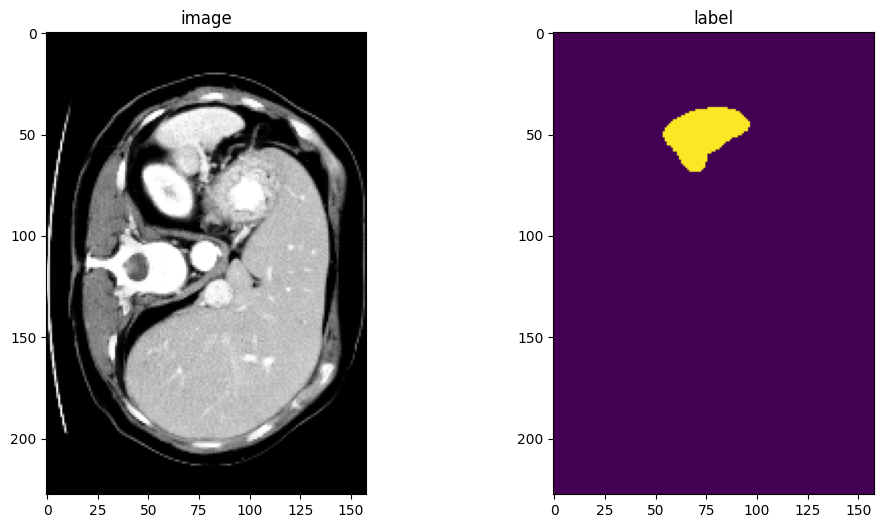

torch.Size([305, 267, 124]) torch.Size([305, 267, 124])


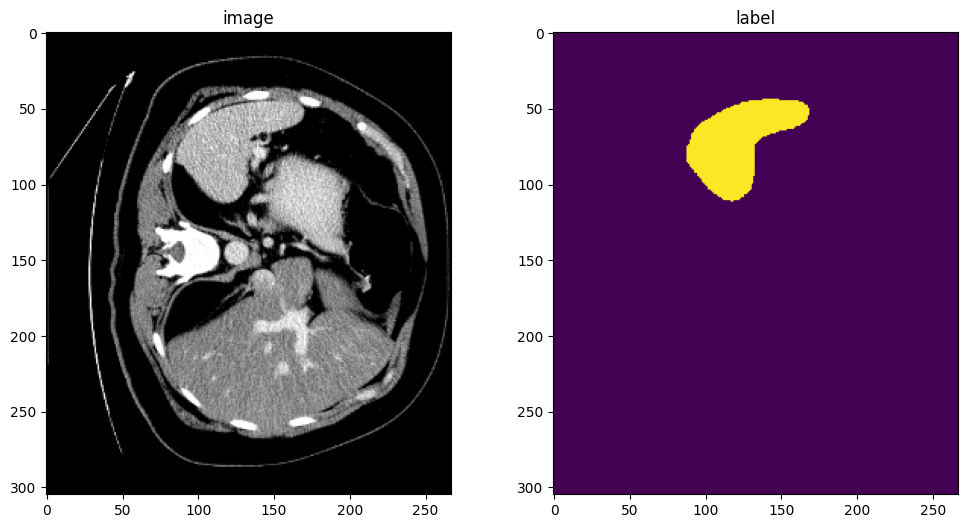

In [12]:
# check transforms in dataloader by presenting first image

check_ds = Dataset(data=val_files, transform=val_transforms) # create a dataset with the validation files and apply the validation transforms to it
check_loader = DataLoader(check_ds, batch_size=1) # create a dataloader to load the data in batches, batch size of 1 is used here to check the transforms on a single image
check_data = first(check_loader)
image, label = (check_data["image"][0][0], check_data["label"][0][0])

print(f"image shape: {image.shape}, label shape: {label.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, 80], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 80])
plt.show()


for i, batch in enumerate(check_loader):
    if i == 1:
        image = batch["image"][0][0]
        label = batch["label"][0][0]
        print(image.shape, label.shape)
        
        plt.figure("check", (12, 6))
        plt.subplot(1, 2, 1)
        plt.title("image")
        plt.imshow(image[:, :, 80], cmap="gray")
        plt.subplot(1, 2, 2)
        plt.title("label")
        plt.imshow(label[:, :, 80])
        plt.show()
        
        break
    else:
        continue


# Task 2 -  Building the full transform Pipeline + DataLoader
1. Seperate Train and validation transforms
2. Train/Val split from dataset.json
3. DataLoader for both

In [13]:

# Preprocessing for training data (Task 2)
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0)),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
        RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(96,96,96)),
        RandFlipd(keys=["image", "label"], prob=0.5),
    ]
)

# Preprocessing for validation data (task 2)
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0)),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    ]
)

In [15]:
# Train/Validation split (Task 2) from dataset.json
# Take the training data defined in the json file and split it into training and validation sets using an 80/20 split.
# We still have the test data defined in the json file but we are keeping that seperate for final evaluation.
with open(os.path.join(data_dir, "dataset.json")) as f:
    datalist = json.load(f)["training"]

# Convert relative paths to absolute paths and normalize slashes
for item in datalist:
    # Remove leading ./ if present
    img_path = item["image"].lstrip("./")
    lbl_path = item["label"].lstrip("./")
    # Join with data_dir to make absolute, then normalize all slashes
    item["image"] = os.path.normpath(os.path.join(data_dir, img_path))
    item["label"] = os.path.normpath(os.path.join(data_dir, lbl_path))

# 80/20 split
train_files = datalist[:int(len(datalist)*0.8)]
val_files = datalist[int(len(datalist)*0.8):]

In [16]:
# Check the structure of dataset.json
print("First item in datalist:")
print(datalist[0])
print(f"Type: {type(datalist[0])}")

First item in datalist:
{'image': 'C:\\DataSets\\Medical_Segmentation_Decathlon\\Task09_Spleen\\Task09_Spleen\\imagesTr\\spleen_19.nii.gz', 'label': 'C:\\DataSets\\Medical_Segmentation_Decathlon\\Task09_Spleen\\Task09_Spleen\\labelsTr\\spleen_19.nii.gz'}
Type: <class 'dict'>


In [17]:
# # Create Datasets and Dataloaders for training
# train_ds = Dataset(data=train_files, transform=train_transforms)

# # Debug dataset loading
# print("Checking training dataset...")

# for i in range(len(train_ds)):
#     try:
#         sample = train_ds[i]

#         print(f"Loaded sample {i}")
#         print(f"Image shape: {sample['image'].shape}")
#         print(f"Label shape: {sample['label'].shape}")

#     except Exception as e:
#         print(f"\nERROR loading sample {i}")
#         print(f"Image path: {train_files[i]['image']}")
#         print(f"Label path: {train_files[i]['label']}")
#         print(f"Exception: {e}")

#         break
    
#     break

# train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)

# val_ds = Dataset(data=val_files, transform=val_transforms)
# val_loader = DataLoader(val_ds, batch_size=2, num_workers=0)


# Create Datasets and Dataloaders for training
train_ds = Dataset(data=train_files, transform=train_transforms)

# Debug dataset loading
print("Checking training dataset...")
print(f"Total samples in dataset: {len(train_ds)}")

for i in range(len(train_ds)):
    try:
        print(i)
        sample = train_ds[i]
        
        print(f"\n--- Sample {i} ---")
        print(f"Type of sample: {type(sample)}")
        print(f"Sample: {sample}")
        
        if isinstance(sample, list):
            print(f"⚠️ Sample is a LIST with {len(sample)} items")
            print(f"Type of first item: {type(sample[0])}")
            if isinstance(sample[0], dict):
                print(f"Keys in first item: {sample[0].keys()}")
            sample = sample[0]
        elif isinstance(sample, dict):
            print(f"✓ Sample is a DICT")
            print(f"Keys: {sample.keys()}")
        else:
            print(f"❌ Unexpected type: {type(sample)}")

        print(f"Image shape: {sample['image'].shape}")
        print(f"Label shape: {sample['label'].shape}")

    except Exception as e:
        print(f"\nERROR loading sample {i}")
        print(f"Image path: {train_files[i]['image']}")
        print(f"Label path: {train_files[i]['label']}")
        print(f"Exception type: {type(e).__name__}")
        print(f"Exception: {e}")
        import traceback
        traceback.print_exc()
        break
    
    if(i == 5):
        break

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)

Checking training dataset...
Total samples in dataset: 32
0

--- Sample 0 ---
Type of sample: <class 'list'>
Sample: [{'image': metatensor([[[[0.6682, 0.6394, 0.6196,  ..., 0.1381, 0.3392, 0.5402],
          [0.6654, 0.6444, 0.6068,  ..., 0.3025, 0.4362, 0.5699],
          [0.6335, 0.5693, 0.4437,  ..., 0.0546, 0.2675, 0.4804],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.3753, 0.4122, 0.4491],
          [0.0000, 0.0000, 0.0000,  ..., 0.4147, 0.3402, 0.2656],
          [0.0000, 0.0975, 0.4185,  ..., 0.6329, 0.5655, 0.4981]],

         [[0.7956, 0.7551, 0.6540,  ..., 0.3957, 0.5003, 0.6050],
          [0.7027, 0.6514, 0.5363,  ..., 0.2677, 0.4582, 0.6488],
          [0.7198, 0.6528, 0.5238,  ..., 0.0993, 0.3454, 0.5916],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.4871, 0.5251, 0.5630],
          [0.0000, 0.0000, 0.0000,  ..., 0.3040, 0.3120, 0.3200],
          [0.0000, 0.0000, 0.0000,  ..., 0.4683, 0.3933, 0.3182]],

         [[0.7136, 0.6587, 0.5765,  ..., 0

# Task 3 - Defining Model & MLFlow
- Define model
- setup MLflow

In [18]:
device = torch.device("cuda:0") # GPU is used for training

model = UNet(
    spatial_dims=3, # configure model to use 3D convolutions
    in_channels=1, # input: grayscale image
    out_channels=2, # output: spleen and background segmentation
    channels=(16, 32, 64, 128, 256), # Define number  f filters in each layer
    strides=(2, 2, 2, 2), # downsample
    num_res_units=2,
    norm=Norm.BATCH, # use batch normalization for better stability
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [19]:
# setup mlflow for experiment tracking
# mlflow is used to log the parameters and metrics of the training process, allowing to track performance

mlflow.set_experiment("spleen-segmentation")

with mlflow.start_run():
    mlflow.log_params({
        "model": "UNet",
        "epochs": 600, # number of training epochs, may need to reduce
        "batch_size": 2,
        "learning_rate": 1e-4,
        "patch_size": "96x96x96",
        "dataset": "Task09_Spleen"
    })

# Task 4 - Training Loop
- training loop
- postprocessing

In [20]:
# post processing transforms
post_pred = AsDiscrete(argmax=True, to_onehot=2)
post_label = AsDiscrete(to_onehot=2)

In [21]:
# # Training loop
# best_metric = -1
# best_metric_epoch = -1
# epoch_loss_values = []
# metric_values = []

# max_epochs = 600
# val_interval = 2  # validate every 2 epochs

# with mlflow.start_run():
#     mlflow.log_params({
#         "model": "UNet",
#         "epochs": max_epochs,
#         "batch_size": 2,
#         "learning_rate": 1e-4,
#         "patch_size": "96x96x96",
#         "dataset": "Task09_Spleen"
#     })

#     for epoch in range(max_epochs):
#         model.train()
#         epoch_loss = 0

#         for batch_data in train_loader:
#             inputs = batch_data["image"].to(device)
#             labels = batch_data["label"].to(device)

#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = loss_function(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             epoch_loss += loss.item()

#         epoch_loss /= len(train_loader)
#         epoch_loss_values.append(epoch_loss)

#         # log train loss to MLflow every epoch
#         mlflow.log_metric("train_loss", epoch_loss, step=epoch)
#         print(f"Epoch {epoch+1}/{max_epochs} — loss: {epoch_loss:.4f}")

#         # validation
#         if (epoch + 1) % val_interval == 0:
#             model.eval()
#             with torch.no_grad():
#                 for val_data in val_loader:
#                     val_inputs = val_data["image"].to(device)
#                     val_labels = val_data["label"].to(device)

#                     val_outputs = sliding_window_inference(
#                         val_inputs, (96, 96, 96), 4, model
#                     )

#                     val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
#                     val_labels = [post_label(i) for i in decollate_batch(val_labels)]

#                     dice_metric(y_pred=val_outputs, y=val_labels)

#                 metric = dice_metric.aggregate().item()
#                 dice_metric.reset()
#                 metric_values.append(metric)

#                 # log val Dice to MLflow
#                 mlflow.log_metric("val_dice", metric, step=epoch)
#                 print(f"  Val Dice: {metric:.4f}")

#                 # save best model
#                 if metric > best_metric:
#                     best_metric = metric
#                     best_metric_epoch = epoch + 1
#                     torch.save(model.state_dict(), "best_model.pth")
#                     mlflow.log_artifact("best_model.pth")
#                     print(f"  New best model saved — Dice: {best_metric:.4f}")

#     print(f"Training complete. Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")
#     mlflow.log_metric("best_val_dice", best_metric)

In [22]:
# Verify paths before training
print("Verifying training data paths...")
print(f"Number of training files: {len(train_files)}")
print(f"First training image path: {train_files[0]['image']}")
print(f"Path exists: {os.path.exists(train_files[0]['image'])}")
print()
print(f"Number of validation files: {len(val_files)}")
print(f"First validation image path: {val_files[0]['image']}")
print(f"Path exists: {os.path.exists(val_files[0]['image'])}")

Verifying training data paths...
Number of training files: 32
First training image path: C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen\imagesTr\spleen_19.nii.gz
Path exists: True

Number of validation files: 9
First validation image path: C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen\imagesTr\spleen_47.nii.gz
Path exists: True


# Inference & Explainability

In [59]:
# Load the best saved checkpoint
model.load_state_dict(torch.load("checkpoints/best_model.pth"))
model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


In [98]:
# Grab volume in case not defined
val_data = first(val_loader)
val_input = val_data["image"]
val_label = val_data["label"]

# Run sliding window inference on volume
start = time.time()
with torch.no_grad():
    val_output = sliding_window_inference(
        val_input.to(device), (96, 96, 96), 4, model, #overlap=0.5
    )
print(f"Inference time: {time.time() - start:.2f}s")


Inference time: 0.34s


In [99]:
# pick which slice to visualize (80 is a good middle slice)
slice_idx = 186

# original CT scan
slice_ct = val_input[0, 0, :, :, slice_idx].cpu().numpy()

# ground truth label
slice_label = val_label[0, 0, :, :, slice_idx].cpu().numpy()

# predicted mask
val_output_discrete = torch.argmax(val_output, dim=1, keepdim=True)

# remove pixels outside of spleen region [comeback to this after retraining ]
#keep_largest = KeepLargestConnectedComponent(applied_labels=[1])
#val_output_cleaned = keep_largest(val_output_discrete[0])  # remove batch dim 

slice_pred = val_output_discrete[0, 0, :, :, slice_idx].cpu().numpy() #val_output_discrete[0, :, :, slice_idx].cpu().numpy()
#slice_pred = val_output_cleaned[0, :, :, slice_idx].cpu().numpy() # dimenion reduced



In [100]:
# check label values
print("Label unique values:", np.unique(slice_label))
print("Pred unique values:", np.unique(slice_pred))
print("Label shape:", val_label.shape)
print("Val output shape:", val_output.shape)

# find which slices actually contain the spleen
label_vol = val_label[0, 0].cpu().numpy()
spleen_slices = [i for i in range(label_vol.shape[2]) if label_vol[:,:,i].sum() > 0]
print("Slices containing spleen:", spleen_slices)

Label unique values: [0.0000000e+00 6.7286660e-06 1.4968107e-05 1.5547268e-05 2.3320903e-05
 3.8868169e-05 3.8868173e-05 2.2793859e-03 8.9357318e-03 1.0298190e-02
 1.0533097e-02 2.1393223e-02 3.1261779e-02 3.2460179e-02 3.5273265e-02
 4.4725299e-02 4.7961839e-02 4.8252668e-02 5.4109696e-02 5.6139279e-02
 6.2666729e-02 6.4151816e-02 6.6667505e-02 6.7345001e-02 8.9902937e-02
 9.1402806e-02 9.2045180e-02 9.4176292e-02 1.0904501e-01 1.1359368e-01
 1.1639772e-01 1.1791101e-01 1.1933279e-01 1.2027161e-01 1.3187559e-01
 1.3969237e-01 1.4329819e-01 1.4927867e-01 1.5254603e-01 1.5488018e-01
 1.6661055e-01 1.6764095e-01 1.6856256e-01 1.7012872e-01 1.7217885e-01
 1.7244639e-01 1.7719509e-01 1.7779285e-01 1.9017461e-01 1.9702920e-01
 2.0052056e-01 2.0773497e-01 2.0944408e-01 2.2284757e-01 2.2385971e-01
 2.3456722e-01 2.5076020e-01 2.5577644e-01 2.5777435e-01 2.6460066e-01
 2.6863167e-01 2.7759072e-01 2.7763736e-01 2.7867675e-01 2.7974650e-01
 2.8023243e-01 2.9255354e-01 2.9548550e-01 2.9938444e-01

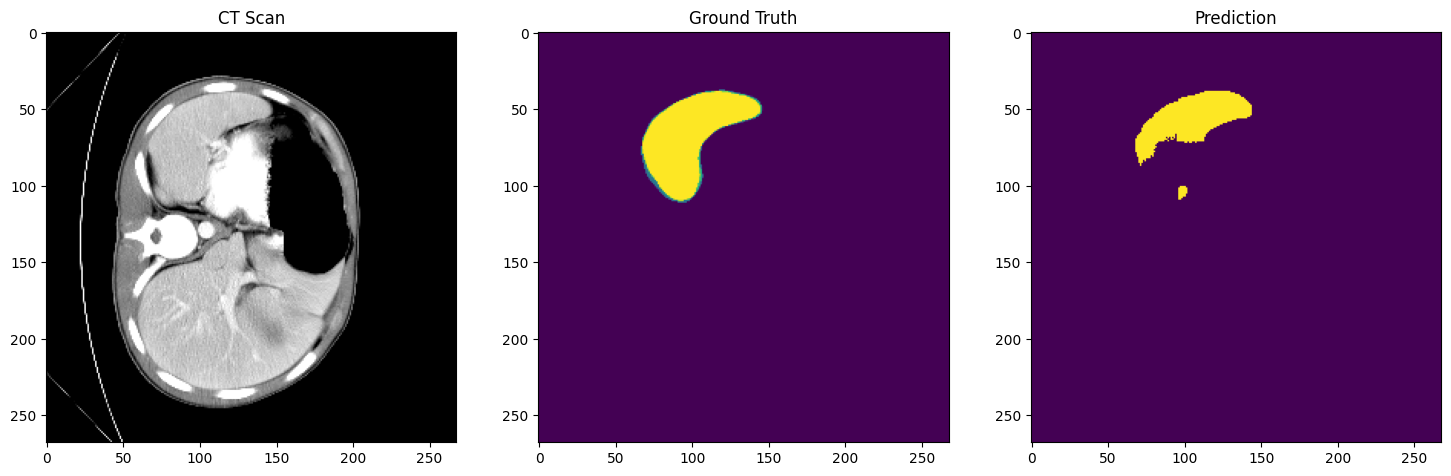

In [101]:
# Visualize results
plt.figure("results", (18, 6))
plt.subplot(1, 3, 1)
plt.title("CT Scan")
plt.imshow(slice_ct, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(slice_label)

plt.subplot(1, 3, 3)
plt.title("Prediction")
plt.imshow(slice_pred)
plt.show()

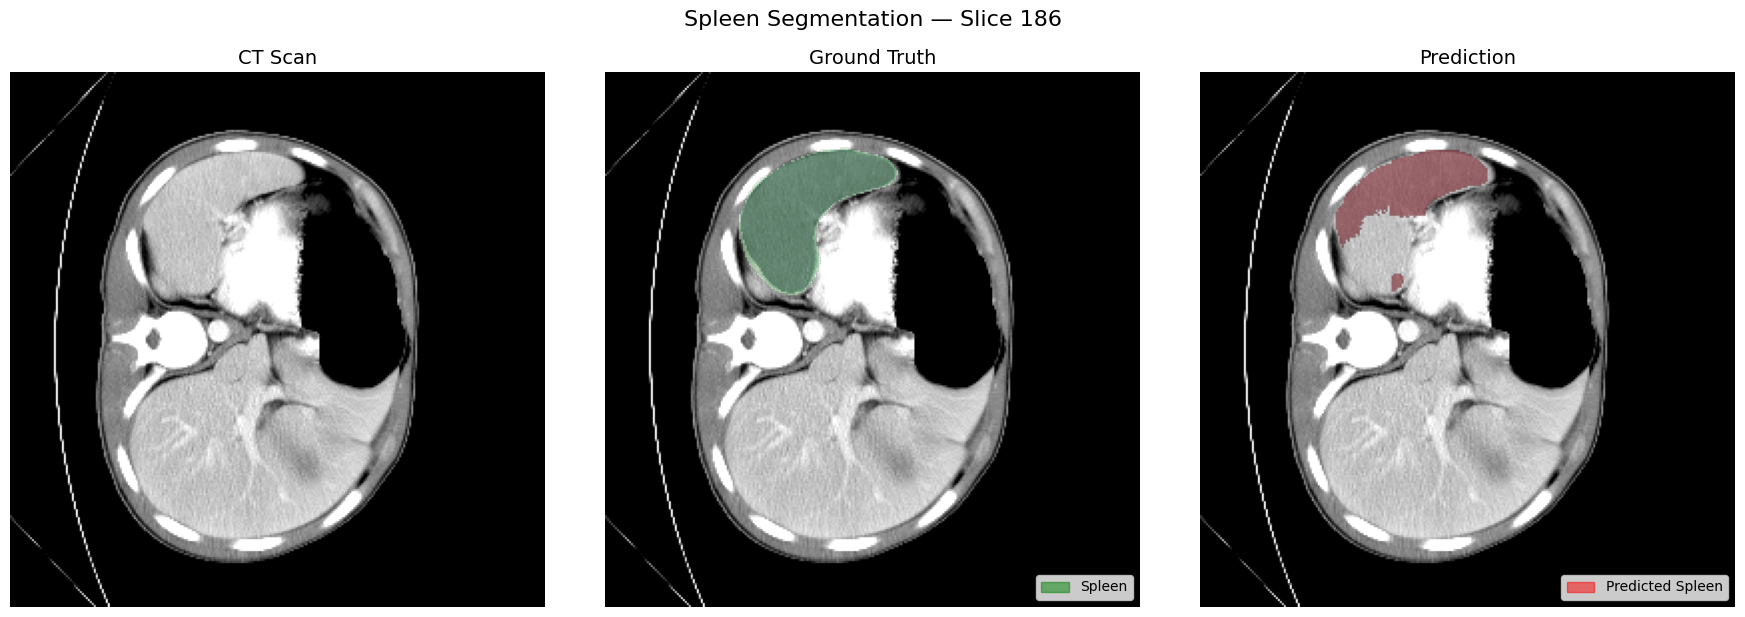

Saved and logged to MLflow


In [102]:
# color coded visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# pick your slice
slice_idx = 186

slice_ct = val_input[0, 0, :, :, slice_idx].cpu().numpy()
slice_label = val_label[0, 0, :, :, slice_idx].cpu().numpy()
slice_pred = val_output_discrete[0, 0, :, :, slice_idx].cpu().numpy()

# Panel 1: raw CT
axes[0].imshow(slice_ct, cmap="gray")
axes[0].set_title("CT Scan", fontsize=14)
axes[0].axis("off")

# Panel 2: ground truth overlay
axes[1].imshow(slice_ct, cmap="gray")
axes[1].imshow(np.ma.masked_where(slice_label == 0, slice_label), 
               cmap="Greens", alpha=0.5, vmin=0, vmax=1)
axes[1].set_title("Ground Truth", fontsize=14)
axes[1].axis("off")
green_patch = mpatches.Patch(color="green", alpha=0.5, label="Spleen")
axes[1].legend(handles=[green_patch], loc="lower right")

# Panel 3: prediction overlay
axes[2].imshow(slice_ct, cmap="gray")
axes[2].imshow(np.ma.masked_where(slice_pred == 0, slice_pred), 
               cmap="Reds", alpha=0.5, vmin=0, vmax=1)
axes[2].set_title("Prediction", fontsize=14)
axes[2].axis("off")
red_patch = mpatches.Patch(color="red", alpha=0.5, label="Predicted Spleen")
axes[2].legend(handles=[red_patch], loc="lower right")

plt.suptitle(f"Spleen Segmentation — Slice {slice_idx}", fontsize=16, y=1.02)
plt.tight_layout()

# save and log to MLflow
plt.savefig("prediction_overlay.png", dpi=150, bbox_inches="tight")
mlflow.log_artifact("prediction_overlay.png")
plt.show()
print("Saved and logged to MLflow")